# Metrics Distribution Visualizations

This notebook visualizes the distributions of key behavioral and engagement metrics using histograms.

## Import Required Libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration - Percentile Bounds

In [23]:
# Set percentile bounds for visualizations
# This removes outliers from the top and bottom of distributions
PERCENTILE_LOWER = 5  # Remove bottom 2.5%
PERCENTILE_UPPER = 95  # Remove top 2.5%

print(f"Displaying data between {PERCENTILE_LOWER}th and {PERCENTILE_UPPER}th percentiles")
print(f"This excludes the bottom {PERCENTILE_LOWER}% and top {100-PERCENTILE_UPPER}% of data")

Displaying data between 5th and 95th percentiles
This excludes the bottom 5% and top 5% of data


## Load Data

In [24]:
# Load the merged analytic scores dataset
df = pd.read_csv("../data/processed_data/merged_analytic_scores.csv")

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (20174, 34)

Columns: ['WALLET', 'TX_PER_MONTH', 'TOKEN_DIVERSITY', 'PROTOCOL_DIVERSITY', 'TOTAL_TRANSFER_USD', 'INTERACTION_DIVERSITY', 'ACTIVE_DURATION_DAYS', 'AVG_TRANSFER_USD', 'USD_TRANSFER_STDDEV', 'DEX_EVENTS', 'GAMES_EVENTS', 'CEX_EVENTS', 'DAPP_EVENTS', 'CHADMIN_EVENTS', 'DEFI_EVENTS', 'BRIDGE_EVENTS', 'NFT_EVENTS', 'TOKEN_EVENTS', 'FLOTSAM_EVENTS', 'BRIDGE_OUTFLOW_COUNT', 'BRIDGE_INFLOW_COUNT', 'BRIDGE_TOTAL_VOLUME_USD', 'activity_cluster_label', 'BEHAVIOURAL_VOLATILITY_SCORE', 'CROSS_DOMAIN_ENGAGEMENT_SCORE', 'REVENUE_SCORE_PROXY', 'DEX_EVENTS_MEDIAN', 'CEX_EVENTS_MEDIAN', 'BRIDGE_EVENTS_MEDIAN', 'DEFI_EVENTS_MEDIAN', 'DEX_EVENTS_INTERACTION_MODE', 'CEX_EVENTS_INTERACTION_MODE', 'BRIDGE_EVENTS_INTERACTION_MODE', 'DEFI_EVENTS_INTERACTION_MODE']

First few rows:


,WALLET,TX_PER_MONTH,TOKEN_DIVERSITY,PROTOCOL_DIVERSITY,TOTAL_TRANSFER_USD,INTERACTION_DIVERSITY,ACTIVE_DURATION_DAYS,AVG_TRANSFER_USD,USD_TRANSFER_STDDEV,DEX_EVENTS,...,CROSS_DOMAIN_ENGAGEMENT_SCORE,REVENUE_SCORE_PROXY,DEX_EVENTS_MEDIAN,CEX_EVENTS_MEDIAN,BRIDGE_EVENTS_MEDIAN,DEFI_EVENTS_MEDIAN,DEX_EVENTS_INTERACTION_MODE,CEX_EVENTS_INTERACTION_MODE,BRIDGE_EVENTS_INTERACTION_MODE,DEFI_EVENTS_INTERACTION_MODE
0,0xecb113be97a619aa4d070491505847000f964448,8.166667,6,9,2840.47,5,177,41.166232,88.745481,5,...,0.496545,331.487269,29.0,2.0,29.0,12.0,24.0,2.0,28.0,12.0
1,0x76c1cf35f54c67bc4fec5ba1411f5c0825a4a50d,8.666667,2,8,3733.59,10,172,56.569545,185.180716,1,...,0.413817,215.907106,29.0,2.0,29.0,12.0,28.0,2.0,29.0,12.0
2,0x2465ba1d82c7faf5cfc1b4f0e3c606800e1caac9,13.000000,5,26,3771.93,14,169,62.865500,135.890912,0,...,0.735509,326.900600,29.0,2.0,29.0,12.0,29.0,2.0,23.0,12.0
3,0xa5a1a2abcc2b67990b37b749c4e840f1fa093c97,6.833333,1,2,12977.28,2,170,370.779429,318.130714,0,...,0.000000,1013.463722,29.0,2.0,29.0,12.0,29.0,2.0,29.0,12.0
4,0xa967e15e71455940dfab4c08719abae50401babd,7.500000,5,6,18935.76,6,156,236.697000,478.737614,5,...,0.819448,1425.823250,29.0,2.0,29.0,12.0,24.0,2.0,19.0,12.0


## Behavioural Volatility Score Distribution

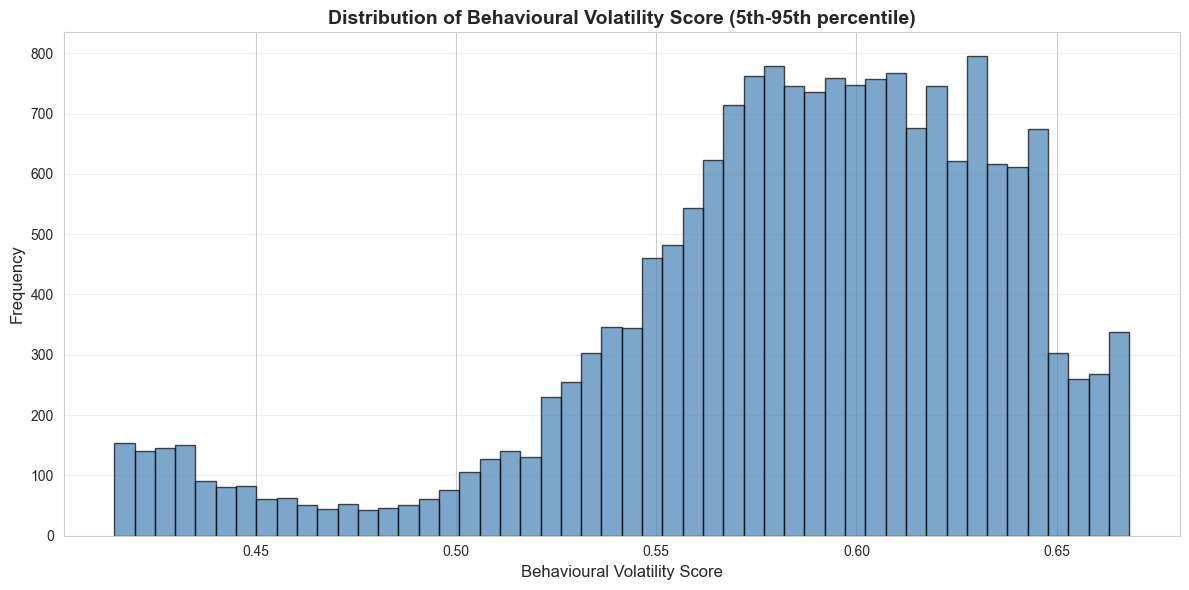

Behavioural Volatility Score Statistics (filtered):
count    18156.000000
mean         0.583370
std          0.053896
min          0.414630
25%          0.558822
50%          0.591104
75%          0.622329
max          0.668147
Name: BEHAVIOURAL_VOLATILITY_SCORE, dtype: float64

Filtered range: [0.41, 0.67]
Data points shown: 18156 / 20174 (90.0%)


In [25]:
# Filter data based on percentile bounds
data = df['BEHAVIOURAL_VOLATILITY_SCORE'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Behavioural Volatility Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Behavioural Volatility Score ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Behavioural Volatility Score Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Cross Domain Engagement Score Distribution

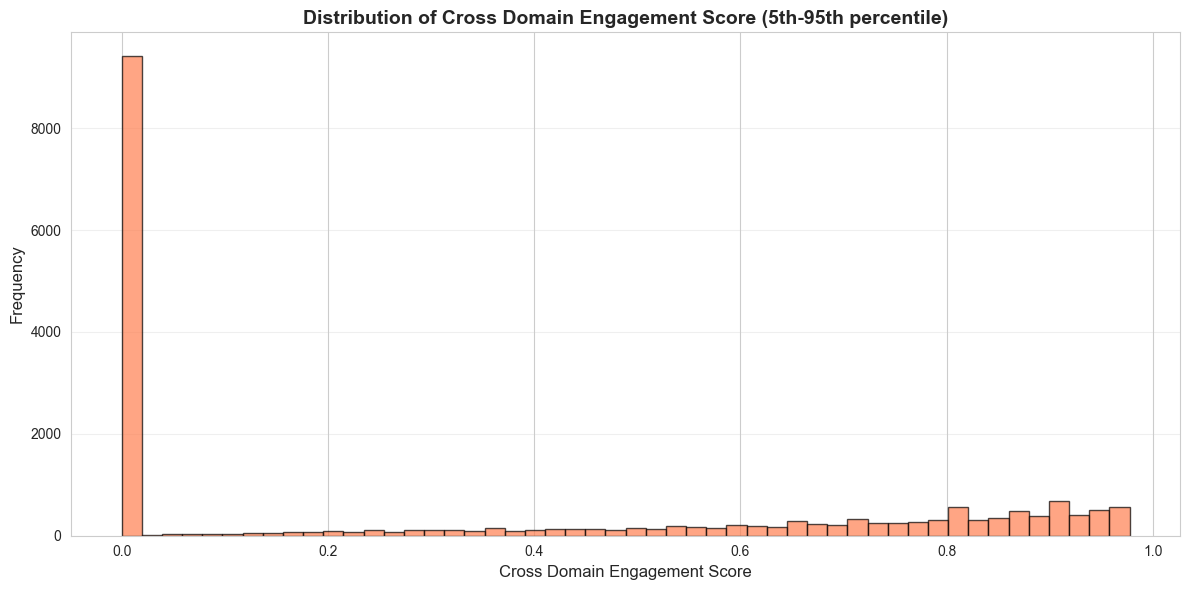

Cross Domain Engagement Score Statistics (filtered):
count    19171.000000
mean         0.352379
std          0.384188
min          0.000000
25%          0.000000
50%          0.134240
75%          0.765479
max          0.977418
Name: CROSS_DOMAIN_ENGAGEMENT_SCORE, dtype: float64

Filtered range: [0.00, 0.98]
Data points shown: 19171 / 20174 (95.0%)


In [26]:
# Filter data based on percentile bounds
data = df['CROSS_DOMAIN_ENGAGEMENT_SCORE'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Cross Domain Engagement Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Cross Domain Engagement Score ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Cross Domain Engagement Score Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Revenue Score Proxy Distribution

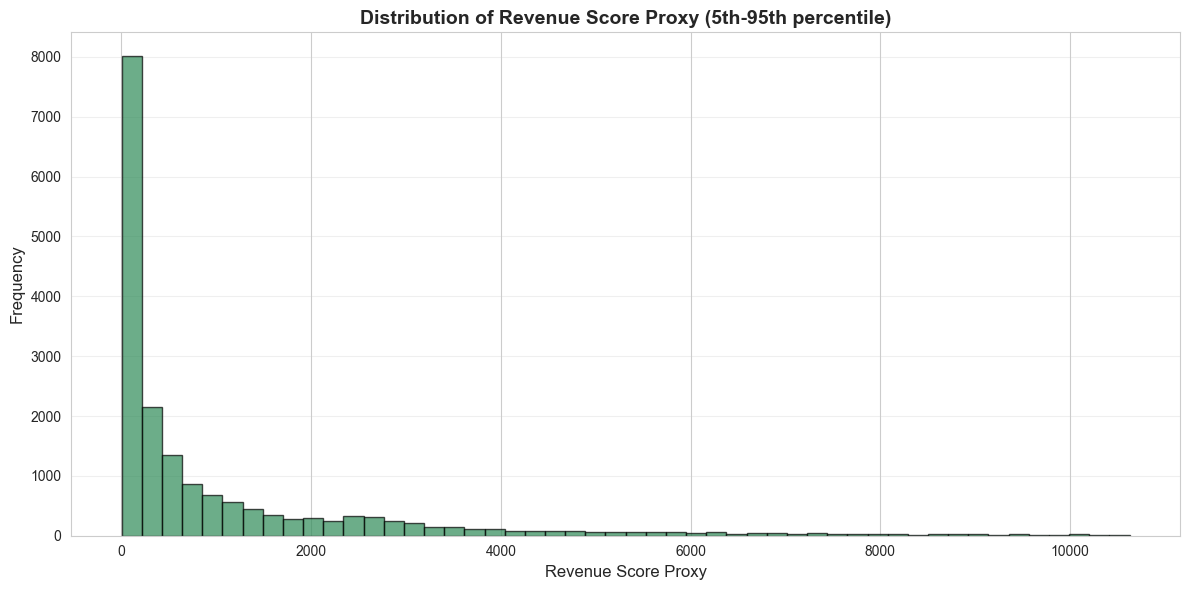

Revenue Score Proxy Statistics (filtered):
count    18156.000000
mean      1099.792563
std       1806.965165
min          1.996786
25%         65.981799
50%        299.833958
75%       1272.693169
max      10629.073511
Name: REVENUE_SCORE_PROXY, dtype: float64

Filtered range: [2.00, 10629.51]
Data points shown: 18156 / 20174 (90.0%)


In [27]:
# Filter data based on percentile bounds
data = df['REVENUE_SCORE_PROXY'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='seagreen')
plt.xlabel('Revenue Score Proxy', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Revenue Score Proxy ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Revenue Score Proxy Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Interaction Diversity Distribution

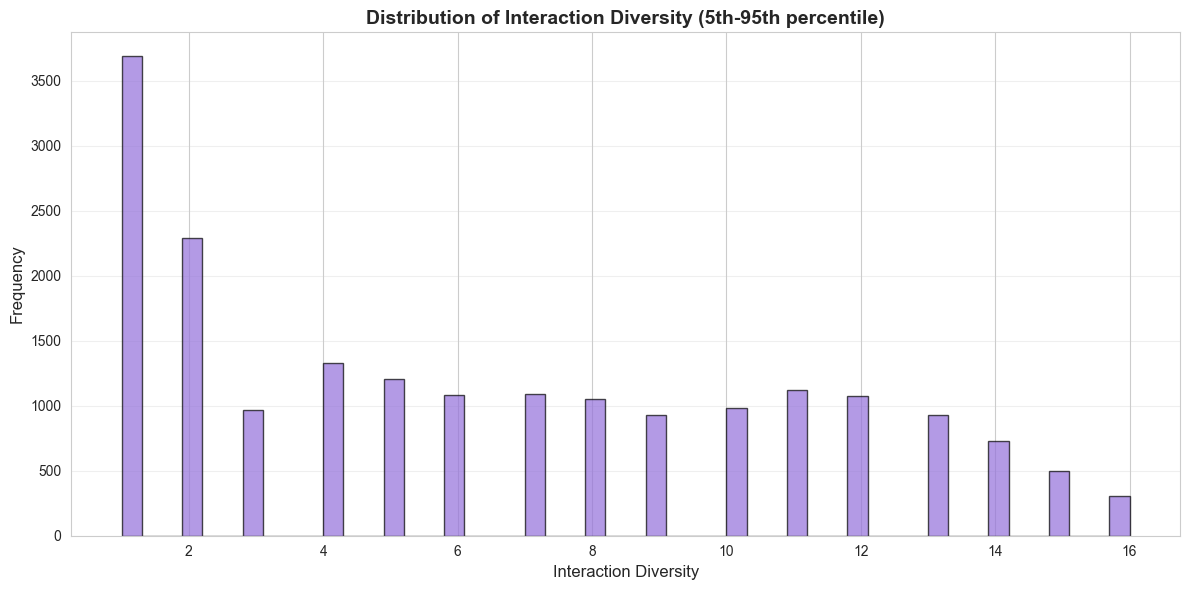

Interaction Diversity Statistics (filtered):
count    19271.000000
mean         6.388978
std          4.559189
min          1.000000
25%          2.000000
50%          6.000000
75%         10.000000
max         16.000000
Name: INTERACTION_DIVERSITY, dtype: float64

Filtered range: [1.00, 16.00]
Data points shown: 19271 / 20174 (95.5%)


In [28]:
# Filter data based on percentile bounds
data = df['INTERACTION_DIVERSITY'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
plt.xlabel('Interaction Diversity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Interaction Diversity ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Interaction Diversity Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Protocol Diversity Distribution

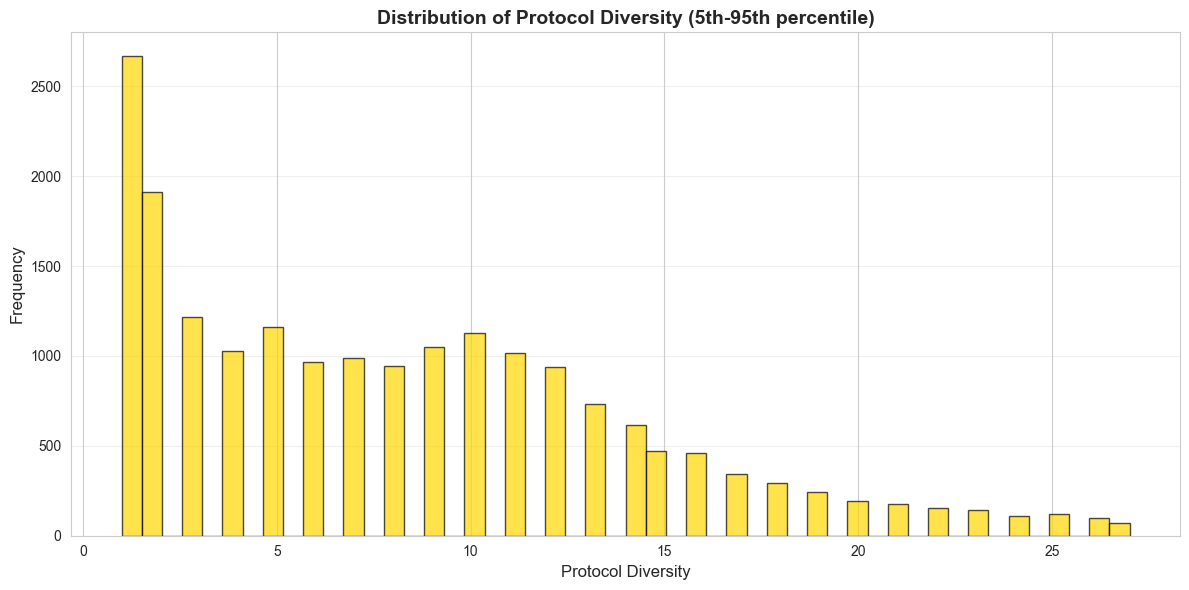

Protocol Diversity Statistics (filtered):
count    19228.000000
mean         8.112128
std          6.079372
min          1.000000
25%          3.000000
50%          7.000000
75%         12.000000
max         27.000000
Name: PROTOCOL_DIVERSITY, dtype: float64

Filtered range: [1.00, 27.00]
Data points shown: 19228 / 20174 (95.3%)


In [29]:
# Filter data based on percentile bounds
data = df['PROTOCOL_DIVERSITY'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='gold')
plt.xlabel('Protocol Diversity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Protocol Diversity ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Protocol Diversity Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Transactions Per Month Distribution

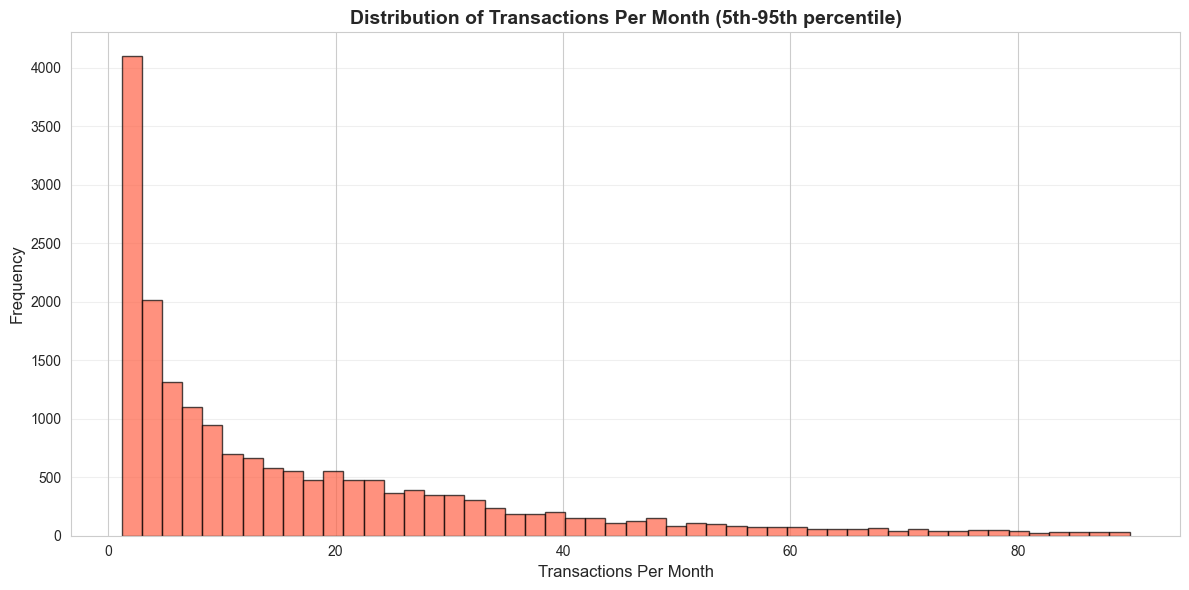

Transactions Per Month Statistics (filtered):
count    18513.000000
mean        16.659807
std         17.954341
min          1.166667
25%          3.333333
50%          9.666667
75%         24.000000
max         89.833333
Name: TX_PER_MONTH, dtype: float64

Filtered range: [1.17, 89.83]
Data points shown: 18513 / 20174 (91.8%)


In [30]:
# Filter data based on percentile bounds
data = df['TX_PER_MONTH'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='tomato')
plt.xlabel('Transactions Per Month', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Transactions Per Month ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Transactions Per Month Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Token Diversity Distribution

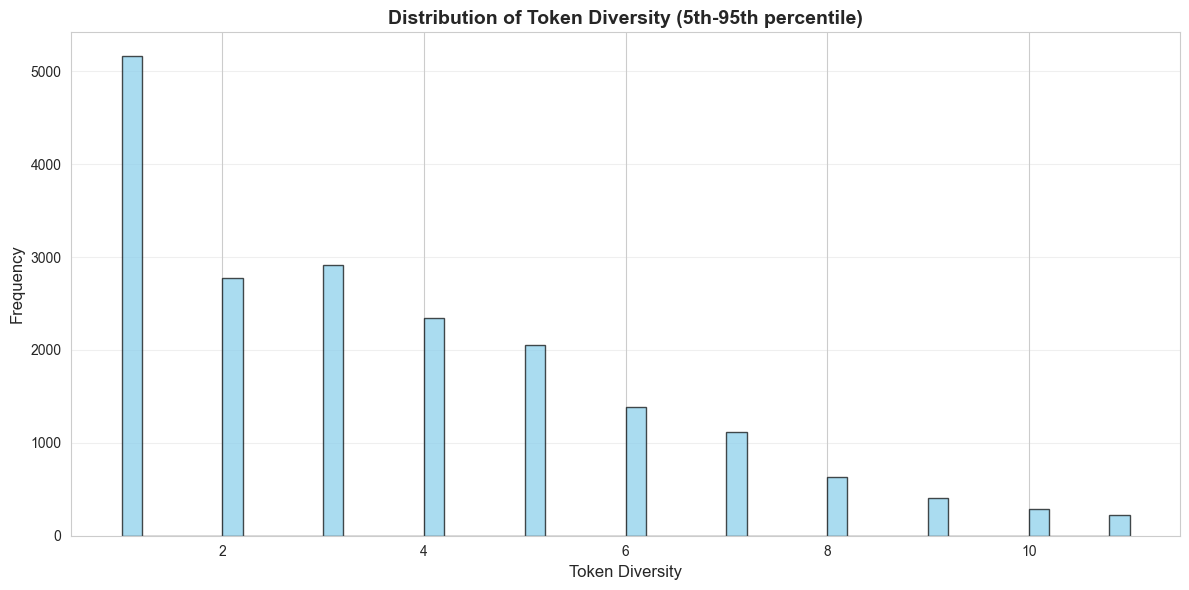

Token Diversity Statistics (filtered):
count    19289.000000
mean         3.589663
std          2.456688
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         11.000000
Name: TOKEN_DIVERSITY, dtype: float64

Filtered range: [1.00, 11.00]
Data points shown: 19289 / 20174 (95.6%)


In [31]:
# Filter data based on percentile bounds
data = df['TOKEN_DIVERSITY'].dropna()
lower_bound = np.percentile(data, PERCENTILE_LOWER)
upper_bound = np.percentile(data, PERCENTILE_UPPER)
data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(12, 6))
plt.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Token Diversity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Token Diversity ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("Token Diversity Statistics (filtered):")
print(data_filtered.describe())
print(f"\nFiltered range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Data points shown: {len(data_filtered)} / {len(data)} ({len(data_filtered)/len(data)*100:.1f}%)")

## Combined Dashboard - All Metrics

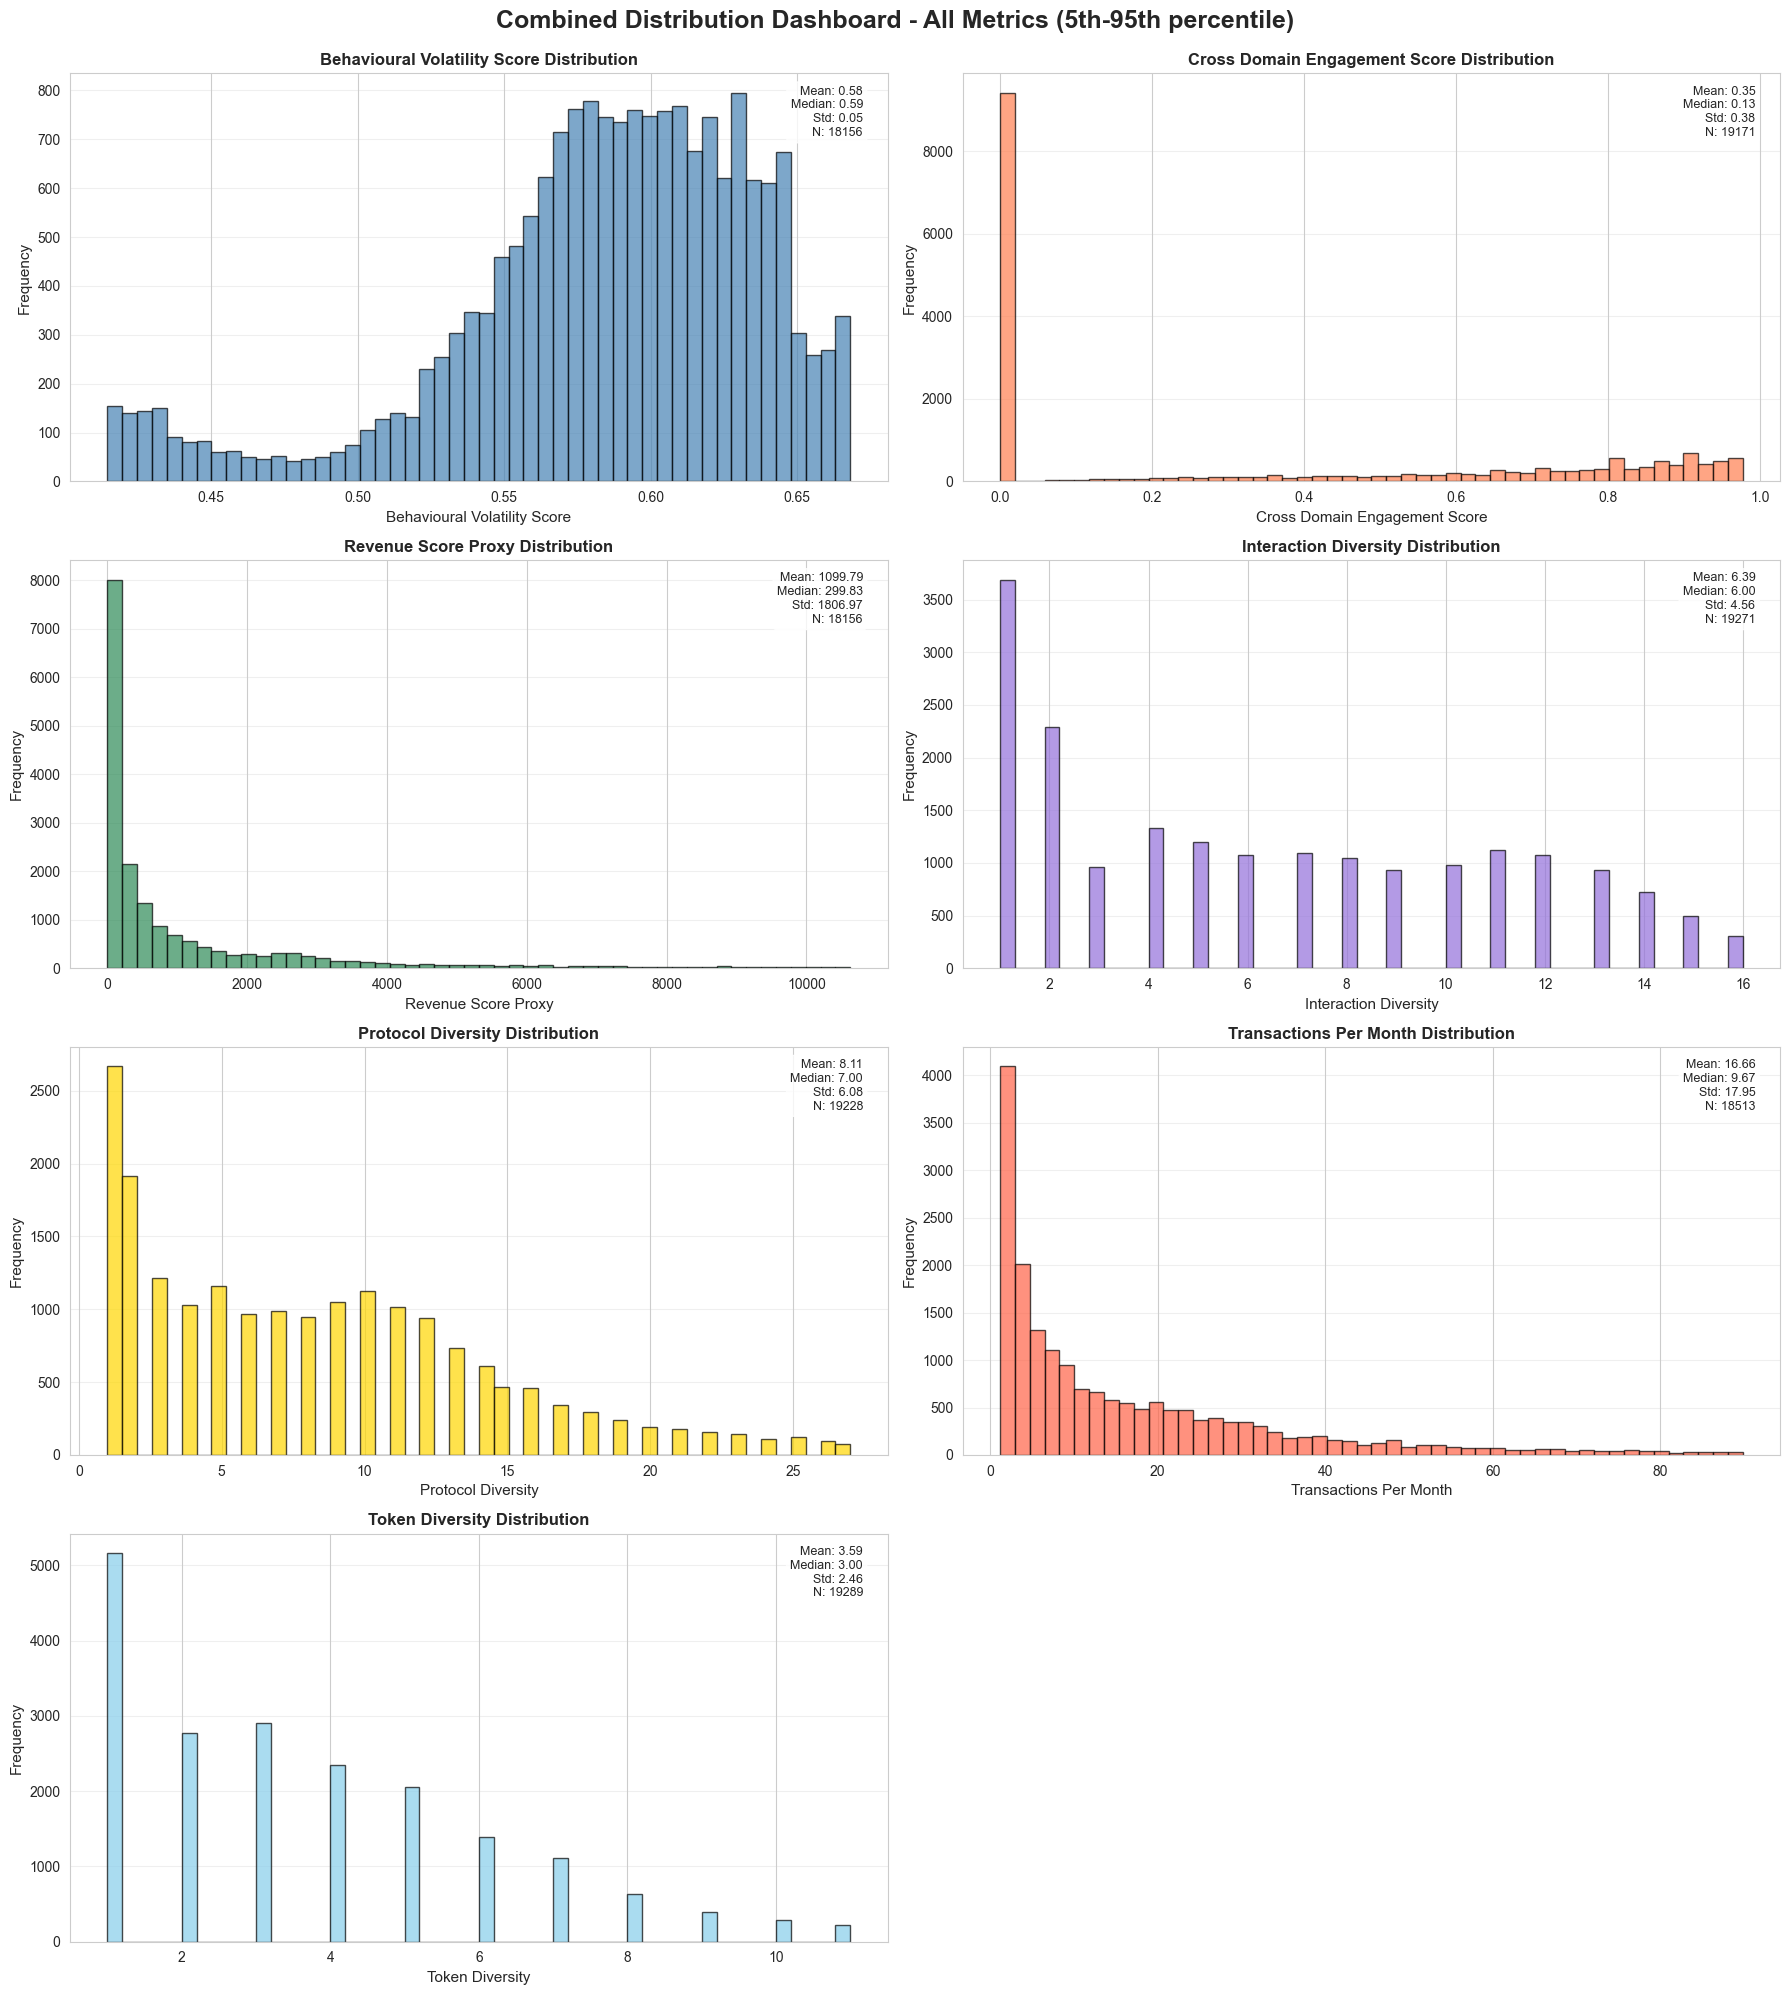

In [32]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle(f'Combined Distribution Dashboard - All Metrics ({PERCENTILE_LOWER}th-{PERCENTILE_UPPER}th percentile)', 
             fontsize=18, fontweight='bold', y=0.995)

# Define metrics and colors
metrics = [
    ('BEHAVIOURAL_VOLATILITY_SCORE', 'Behavioural Volatility Score', 'steelblue'),
    ('CROSS_DOMAIN_ENGAGEMENT_SCORE', 'Cross Domain Engagement Score', 'coral'),
    ('REVENUE_SCORE_PROXY', 'Revenue Score Proxy', 'seagreen'),
    ('INTERACTION_DIVERSITY', 'Interaction Diversity', 'mediumpurple'),
    ('PROTOCOL_DIVERSITY', 'Protocol Diversity', 'gold'),
    ('TX_PER_MONTH', 'Transactions Per Month', 'tomato'),
    ('TOKEN_DIVERSITY', 'Token Diversity', 'skyblue')
]

# Plot each metric
for idx, (col, title, color) in enumerate(metrics):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row, col_idx]
    
    # Filter data based on percentile bounds
    data = df[col].dropna()
    lower_bound = np.percentile(data, PERCENTILE_LOWER)
    upper_bound = np.percentile(data, PERCENTILE_UPPER)
    data_filtered = data[(data >= lower_bound) & (data <= upper_bound)]
    
    ax.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color=color)
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add summary stats as text
    stats_text = f'Mean: {data_filtered.mean():.2f}\nMedian: {data_filtered.median():.2f}\nStd: {data_filtered.std():.2f}\nN: {len(data_filtered)}'
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=9)

# Hide the last subplot (since we have 7 metrics in 4x2 grid)
axes[3, 1].axis('off')

plt.tight_layout()
plt.show()